In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
%matplotlib inline

In [2]:
df = pd.read_csv('EnyrunData_Merged.csv')

## Checking data

In [4]:
df.head()

,Klient,Netto,VAT,Brutto,Koszt,COUNTA z Klient,Ilość,Zysk,Marża,quit
0,ANMET Anna Kiełbik -Justyna,106,"24,38","130,38","41,4",1,0,0,NaN,1.0
1,BIUREX DUŚ RENATA,"38,88",NaN,"47,82",0,0,0,0,NaN,NaN
2,DAUER Michał Dauer,184,"42,32","226,32","73,32",1,0,0,NaN,1.0
3,Dąbex Józef Nowak i Wspólnicy Spółka Jawna,"626,2","144,03","770,23","284,52",1,0,0,NaN,1.0
4,Emiter Marcin Maluch,"73,01","16,79","89,8",45,1,0,0,NaN,1.0


In [5]:
df.describe()

,COUNTA z Klient,quit
count,5492.000000,4822.000000
mean,4.442280,0.887391
std,15.297015,0.316147
min,0.000000,0.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,2.000000,1.000000
max,399.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5492 entries, 0 to 5491
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Klient           5492 non-null   object 
 1   Netto            5492 non-null   object 
 2   VAT              4822 non-null   object 
 3   Brutto           5492 non-null   object 
 4   Koszt            5492 non-null   object 
 5   COUNTA z Klient  5492 non-null   int64  
 6   Ilość            5492 non-null   object 
 7   Zysk             5492 non-null   object 
 8   Marża            4299 non-null   object 
 9   quit             4822 non-null   float64
dtypes: float64(1), int64(1), object(8)
memory usage: 429.2+ KB


In [7]:
df.isna().sum()

Klient                0
Netto                 0
VAT                 670
Brutto                0
Koszt                 0
COUNTA z Klient       0
Ilość                 0
Zysk                  0
Marża              1193
quit                670
dtype: int64

In [8]:
# Replace commas with dots in columns
df[['VAT', 'Marża', 'Netto', 'Brutto', 'Koszt', 'Ilość', 'Zysk']] = df[['VAT', 'Marża', 'Netto', 'Brutto', 'Koszt', 'Ilość', 'Zysk']].apply(lambda x: x.str.replace(',', '.')).astype(float)

In [9]:
# Convert VAT column to numeric, forcing errors to NaN
df['VAT'] = pd.to_numeric(df['VAT'], errors='coerce')
# Convert Marża column to numeric, forcing errors to NaN
df['Marża'] = pd.to_numeric(df['Marża'], errors='coerce')
# Fill NaN values with the mean of the VAT column
df['VAT'] = df['VAT'].fillna(df['VAT'].mean())
df['Marża'] = df['Marża'].fillna(df['Marża'].mean())

In [10]:
df.isna().sum()

Klient               0
Netto                0
VAT                  0
Brutto               0
Koszt                0
COUNTA z Klient      0
Ilość                0
Zysk                 0
Marża                0
quit               670
dtype: int64

In [11]:
# Drop remaining NaN values
df = df.dropna()
df.isna().sum()

Klient             0
Netto              0
VAT                0
Brutto             0
Koszt              0
COUNTA z Klient    0
Ilość              0
Zysk               0
Marża              0
quit               0
dtype: int64

In [12]:
df = df.drop(['Klient'], axis=1)
df.head()

,Netto,VAT,Brutto,Koszt,COUNTA z Klient,Ilość,Zysk,Marża,quit
0,106.00,24.38,130.38,41.40,1,0.0,0.0,54.58879,1.0
2,184.00,42.32,226.32,73.32,1,0.0,0.0,54.58879,1.0
3,626.20,144.03,770.23,284.52,1,0.0,0.0,54.58879,1.0
4,73.01,16.79,89.80,45.00,1,0.0,0.0,54.58879,1.0
6,880.00,202.40,1082.40,311.48,1,0.0,0.0,54.58879,0.0


## ANN model

In [14]:
from tensorflow.keras.utils import to_categorical

X = df.drop('quit', axis = 1)
y = to_categorical(df.quit)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [16]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [17]:
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import BatchNormalization

model = Sequential()

# adding the first input layer and the first hidden layer
model.add(Dense(12, kernel_initializer = 'normal', activation = 'relu', input_shape = (8, )))

# adding batch normalization and dropout layer
model.add(Dropout(rate = 0.05))
model.add(BatchNormalization())

# adding the third hidden layer
model.add(Dense(8, kernel_initializer = 'normal', activation = 'relu'))

# adding batch normalization and dropout layer
model.add(Dropout(rate = 0.05))
model.add(BatchNormalization())

# adding the output layer
model.add(Dense(2, kernel_initializer = 'normal', activation = 'sigmoid'))

# compiling the model
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

# fitting the model to the training set 
model_history = model.fit(X_train, y_train, validation_split = 0.20, validation_data = (X_test, y_test), epochs = 100)

Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6759 - loss: 0.6651 - val_accuracy: 0.8767 - val_loss: 0.6079
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8361 - loss: 0.5337 - val_accuracy: 0.8777 - val_loss: 0.4940
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8841 - loss: 0.4156 - val_accuracy: 0.8756 - val_loss: 0.4141
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8962 - loss: 0.3227 - val_accuracy: 0.8767 - val_loss: 0.4123
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9017 - loss: 0.2817 - val_accuracy: 0.8788 - val_loss: 0.4572
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9055 - loss: 0.2624 - val_accuracy: 0.8808 - val_loss: 0.5399
Epoch 7/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9108 - loss: 0.2367 - val_accuracy: 0.8860 - val_loss: 0.5232
Epoch 8/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9041 - loss: 0.2472 - val_accu

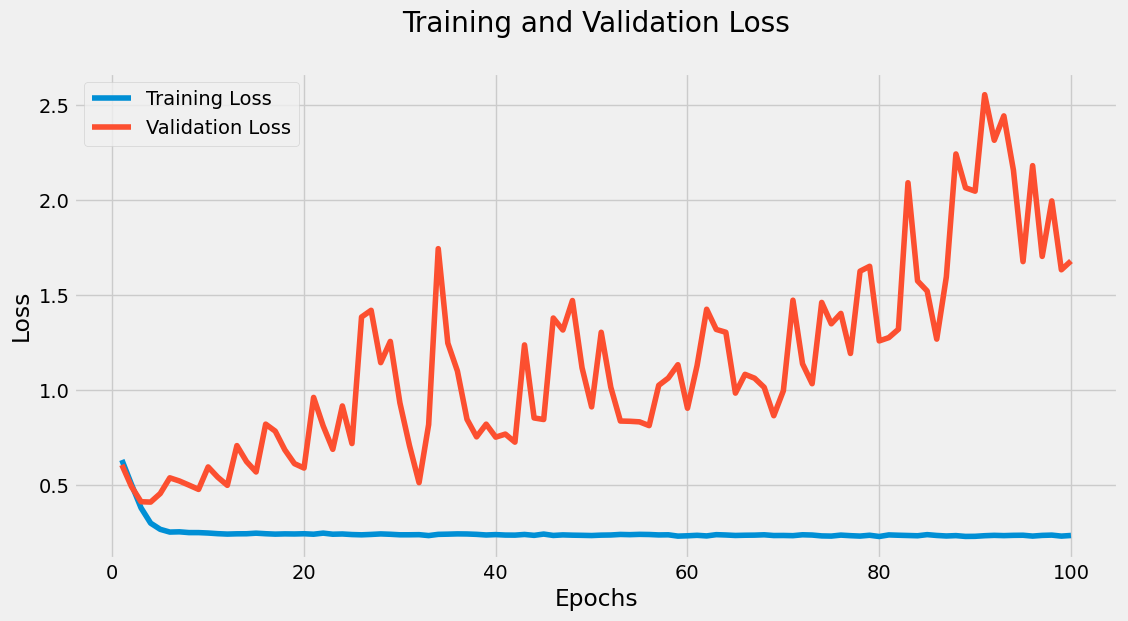

In [18]:
# Extract training and validation loss from the history
train_loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

# Plot the training and validation loss
plt.figure(figsize=(12, 6))
sns.lineplot(x=epochs, y=train_loss, label='Training Loss')
sns.lineplot(x=epochs, y=val_loss, label='Validation Loss')
plt.title('Training and Validation Loss\n')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

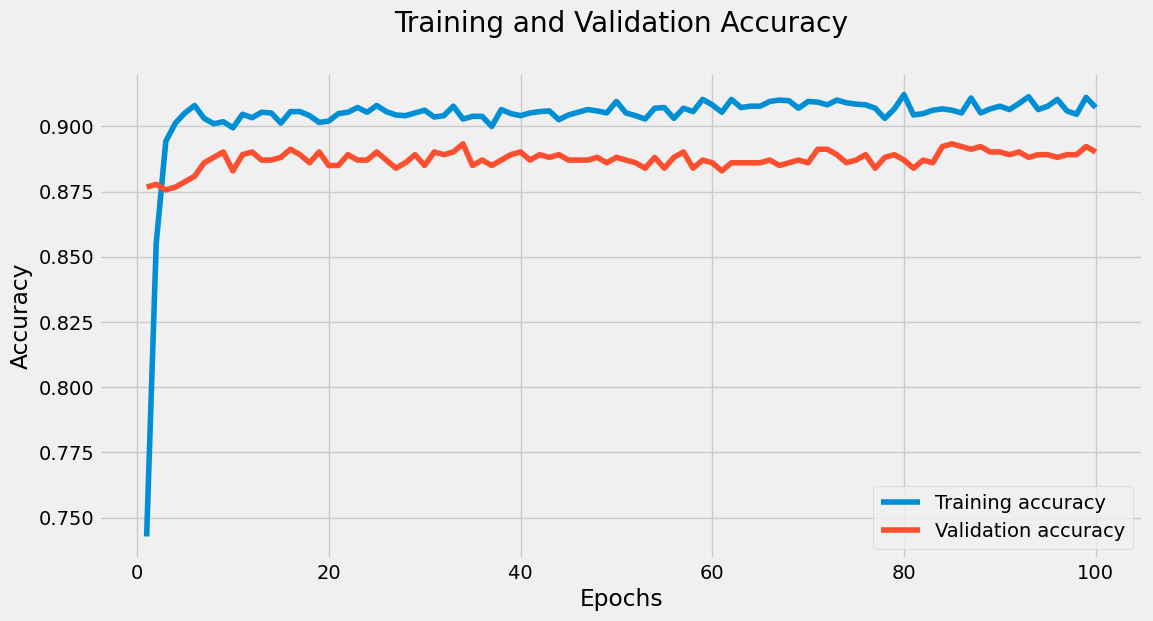

In [19]:
plt.figure(figsize=(12, 6))

train_loss = model_history.history['accuracy']
val_loss = model_history.history['val_accuracy']
epoch = range(1, 101)

# Use x and y keyword arguments for sns.lineplot
sns.lineplot(x=epoch, y=train_loss, label='Training accuracy')
sns.lineplot(x=epoch, y=val_loss, label='Validation accuracy')

plt.title('Training and Validation Accuracy\n')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [20]:
acc = model.evaluate(X_test, y_test)[1]
print(f'Accuracy of model is {acc}')

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8997 - loss: 2.6110 
Accuracy of model is 0.8901554346084595


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12)             │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 852 (3.33 KB)

 Trainable params: 270 (1.05 KB)

 Non-trainable params: 40 (160.00 B)

 Optimizer params: 542 (2.12 KB)